# 1a. Analysis

Этап анализа территории

In [2]:
from src import Model
from pydantic import Field

class QueryModel(Model):
    """
    Ключевая информация о запросе пользователя по разработке проекта генерального плана
    """
    settlement_name : str = Field(description='Название населенного пункта')
    settlement_type : str = Field(description='Тип населенного пункта')
    location : str = Field(description='Расположение населенного пункта')
    current_year : int = Field(description='Текущий год')


In [3]:
class TaskModel(Model):
    """
    Задача аналитического этапа, предназначенная для отдельного ответственного лица
    """
    description : str = Field(description='Постановка задачи')
    focus_areas : list[str] = Field(min_length=1, description='Области, на которых необходимо сфокусироваться')
    questions : list[str] = Field(min_length=1, description='На какие вопросы необходимо ответить')
    instructions : list[str] | None = Field(description='Особые указания планировщика')

class PlanModel(Model):
    """
    План проведения аналитического этапа разработки проекта генерального плана населенного пункта
    """
    tasks : dict[str,TaskModel] = Field(min_length=1, description='Независимые параллельные задачи аналитического этапа, предназначенные для отдельных ответственных лиц')

In [4]:
class TaskResultsModel(Model):
    """
    Результаты проведения аналитического этапа разработки проекта генерального плана населенного пункта в контексте отдельной задачи с указанием источников
    """
    results : list[str] = Field(description='Полученные результаты с указанием источников')
    sources : dict[int, str] = Field(description='Источники (документы)')

class PlanResultsModel(Model):
    """
    Результаты проведения аналитического этапа разработки проекта генерального плана населенного пункта
    """
    tasks : dict[str, TaskResultsModel] = Field(description='Результаты аналитического этапа по каждой задаче')

In [5]:
class TaskCritiqueModel(Model):
    """
    Критика в контексте отдельной задачи
    """
    score : int = Field(ge=2, le=5, description='Оценка результатов задачи от 2 до 5')
    reliability : int = Field(ge=2, le=5, description='Оценка достоверности результатов от 2 до 5')
    strengths : list[str] = Field(description='Сильные стороны результатов выполненной задачи')
    weaknesses : list[str] = Field(description='Слабые стороны результатов выполненной задачи')
    recommendations: list[str] = Field(description="Рекомендации к исправлению")
    missing_aspects : list[str] = Field(description='Какие важные аспекты не были освещены')

class CritiqueModel(Model):
    """
    Комплексная критика всего аналитического этапа
    """
    tasks : dict[str, TaskCritiqueModel] = Field(description='Критика по каждой отдельной задаче')
    plan : str = Field(description='Критика по отношению к составленному плану')

In [6]:
class AnalysisState(Model):
    query : QueryModel
    plan : PlanModel | None = None
    results : PlanResultsModel | None = None
    critique : CritiqueModel | None = None
    iteration : int = 0
    max_iterations : int

In [7]:
from src import Agent, search_tool
from langchain.tools import tool

@tool
def rag_tool(query : str):
    """
    Выполняет анализ документов с использованием RAG.
    
    Используй этот инструмент, когда нужно найти и проанализировать информацию 
    из базы знаний, особенно если вопрос требует:
    - Поиска по нескольким документам
    - Синтеза информации из разных источников
    - Структурированного ответа с ссылками на источники
    
    Args:
        query (str): Поисковый запрос

    Returns:
        str: Структурированный ответ на запрос
    """
    print(query)
    agent = Agent(tools=[search_tool], system_prompt="""
    Ты — внутренний поисковый инструмент, который вызывается из основного агента-аналитика.
    
    ТВОЯ ЗАДАЧА:
    Быстро найти информацию по запросу и вернуть ее основному агенту.
    
    КРИТИЧЕСКИ ВАЖНО:
    - Ты должен вернуть результат максимум за 2-3 поиска
    - Основной агент ждет твой ответ и не может делать другие задачи
    - Если будешь искать слишком долго, вся система зависнет
    
    ПРАВИЛО ОСТАНОВКИ:
    После второго поиска ОБЯЗАН вернуть ответ, даже если информация неполная.
    Лучше неполный ответ, чем бесконечный поиск.
    
    ФОРМАТ:
    [ДОСТАТОЧНО] если информации хватает для ответа
    [ЧАСТИЧНО] если информации мало, но больше искать нельзя
    затем сам ответ.
    """)
    return agent.run(query)

In [8]:
from langchain.messages import HumanMessage, AIMessage

def planner_node(state : AnalysisState):
    agent = Agent(response_format=PlanModel, system_prompt="""
    Ты главный архитектор населенного пункта. 
    Твоя задача — на основе запроса и предыдущей критики составить четкий план для команды аналитиков, состоящий из независимых друг от друга задач. 
    План должен быть конкретным и выполнимым.
    """)
    messages = [HumanMessage(str(state.query))]
    if state.plan is not None:
        plan = state.plan
        messages.append(AIMessage(str(plan)))
    if state.critique is not None:
        critique = state.critique
        messages.append(HumanMessage(str(critique)))
    return {
        'plan': agent.run(messages),
        'iteration': state.iteration + 1
    }

In [12]:
planner_node(AnalysisState(query=QueryModel(
    settlement_name='Гатчина',
    settlement_type='город',
    location='Северо-западный федеральный округ, Ленинградская область, Гатчинский муниципальный округ',
    current_year=2026
), max_iterations=3))

{'plan': PlanModel(tasks={'demographic_analysis': TaskModel(description='Анализ демографической ситуации и прогноз численности населения', focus_areas=['Текущая численность населения', 'Возрастная структура', 'Миграционные потоки', 'Естественный прирост/убыль', 'Прогноз численности до 2040 года'], questions=['Какова текущая численность населения Гатчины?', 'Каковы основные демографические тренды (рождаемость, смертность, миграция)?', 'Какова возрастная структура населения?', 'Каков прогноз численности населения на 2030, 2035 и 2040 годы?', 'Какие факторы могут повлиять на демографическое развитие города?'], instructions=['Использовать данные Росстата за последние 5 лет', 'Учесть влияние близости Санкт-Петербурга на миграционные процессы', 'Проанализировать данные по Гатчинскому муниципальному округу в целом', 'Учесть планы развития промышленных и жилых зон']), 'economic_analysis': TaskModel(description='Анализ экономического потенциала и структуры занятости', focus_areas=['Основные отр

In [15]:
from src import store

store._chroma.search('Уровень среднемесячной заработной платы по крупным и средним предприятиям Гатчинского муниципального района', 'mmr', k=5)

[Document(id='bee5b083-a409-4259-8cc6-423bcb59bad8', metadata={'source': './data/documents/ССЭР Всеволожский.docx'}, page_content='Всеволожский муниципальный район по производству продукции растениеводства занимает первое место среди муниципальных районов Ленинградской области, а по производству продукции животноводства – десятое место. Агропромышленный комплекс муниципального района включает отрасли животноводства (молочное и мясное скотоводство, козоводство), растениеводства (выращивание картофеля, овощей открытого и закрытого грунта, цветов, зерновых и кормовых культур, грибоводство), пищевой и перерабатывающей промышленности (мясная и хлебопекарная отрасли, фасовка чая и кофе и др.).'),
 Document(id='3da2da30-66bb-4418-8427-bd1e04633920', metadata={'author': 'Пользователь Windows', 'creationdate': '2018-01-10T10:48:15+03:00', 'source': './data/documents/ССЭР Волосовский.pdf', 'creator': 'Microsoft® Word 2010', 'total_pages': 111, 'moddate': '2018-01-10T10:48:15+03:00', 'producer': 

In [ ]:
акщь

In [85]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
import operator

class ExecutorState(TypedDict):
    query : QueryModel
    results : PlanResultsModel | None
    critique : CritiqueModel | None
    tasks : Annotated[dict, operator.ior]

def _create_analysis_node(name : str, task : TaskModel): 
    def analysis_node(state : ExecutorState):
        system_prompt = {
            'query': str(state['query'])
        }
        if state['results'] is not None:
            system_prompt['results'] = str(state['results'])
        if state['critique'] is not None:
            system_prompt['critique'] = str(state['critique'])
        agent = Agent(tools=[rag_tool], response_format=TaskResultsModel, system_prompt=str(system_prompt))
        result = agent.run(str(task))
        return {
            'tasks': {name:result}
        } 
    return analysis_node

def executor_node(state : AnalysisState):
    graph = StateGraph(ExecutorState)
    for name,task in state.plan.tasks.items():
        graph.add_node(name, _create_analysis_node(name, task))
        graph.add_edge(START, name)
        graph.add_edge(name, END)
    app = graph.compile()
    res = app.invoke({
        'query': state.query,
        'results': state.results,
        'critique': state.critique,
        'tasks': {},
    })
    return {
        'results': PlanResultsModel(**res) 
    }

In [86]:
def critic_node(state : AnalysisState):
    agent = Agent(response_format=CritiqueModel, system_prompt="""
    Ты строгий критик. Оцени результаты выполнения задач и разработанный план.
    """)
    data = {
        'query': state.query,
        'plan': state.plan,
        'results': state.results
    }
    return {
        'critique': agent.run(str(data))
    }
    

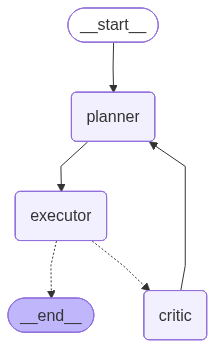

In [ ]:
from langgraph.graph import StateGraph, START, END

analysis_graph = StateGraph(AnalysisState)

analysis_graph.add_node('planner', planner_node)
analysis_graph.add_node('executor', executor_node)
analysis_graph.add_node('critic', critic_node)

analysis_graph.add_edge(START, 'planner')
analysis_graph.add_edge('planner', 'executor')
analysis_graph.add_conditional_edges('executor', lambda s : 'critic' if s.iteration < s.max_iterations else END, ['critic', END])
analysis_graph.add_edge('critic', 'planner')

analysis_app = analysis_graph.compile(debug=True)
analysis_app

In [88]:
input = {
    'query': QueryModel(
        settlement_name='Гатчина',
        settlement_type='город',
        location='Северо-западный федеральный округ, Ленинградская область, Гатчинский муниципальный округ',
        current_year=2026
    ),
    'max_iterations':2
}

str(input['query'])

'{"schema":{"description":"Ключевая информация о запросе пользователя по разработке проекта генерального плана","properties":{"settlement_name":{"description":"Название населенного пункта","title":"Settlement Name","type":"string"},"settlement_type":{"description":"Тип населенного пункта","title":"Settlement Type","type":"string"},"location":{"description":"Расположение населенного пункта","title":"Location","type":"string"},"current_year":{"description":"Текущий год","title":"Current Year","type":"integer"}},"required":["settlement_name","settlement_type","location","current_year"],"title":"QueryModel","type":"object"},"data":{"settlement_name":"Гатчина","settlement_type":"город","location":"Северо-западный федеральный округ, Ленинградская область, Гатчинский муниципальный округ","current_year":2026}}'

In [ ]:
res = analysis_app.invoke(input)

[values] {'query': QueryModel(settlement_name='Гатчина', settlement_type='город', location='Северо-западный федеральный округ, Ленинградская область, Гатчинский муниципальный округ', current_year=2026), 'max_iterations': 2}
[updates] {'planner': {'plan': PlanModel(tasks={'task_1': TaskModel(description='Анализ демографической ситуации и прогноз численности населения', focus_areas=['Текущая численность населения', 'Возрастная структура', 'Миграционные потоки', 'Естественный прирост/убыль', 'Прогноз численности до 2040 года'], questions=['Какова текущая численность населения Гатчины?', 'Каковы тенденции изменения численности населения за последние 10 лет?', 'Какова возрастная структура населения?', 'Каковы основные миграционные потоки (въезд/выезд)?', 'Какой прогноз численности населения к 2040 году?'], instructions=['Использовать данные Росстата за последние 10 лет', 'Проанализировать данные по Гатчинскому муниципальному округу', 'Учесть влияние Санкт-Петербурга на миграционные процессы

In [ ]:
res